# Setup

In [1]:
import os
import pickle
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_absolute_percentage_error as mape

import matplotlib.pyplot as plt
import seaborn as sns

# Start with the default (light) style
plt.style.use('default')

# Now update the rcParams to match your desired white-background style
plt.rcParams.update({
    'axes.facecolor': 'white',         # axes background
    'figure.facecolor': 'white',       # figure background
    'axes.edgecolor': 'black',         # border of plot
    'axes.labelcolor': 'black',        # axis labels
    'xtick.color': 'black',
    'ytick.color': 'black',
    'grid.color': 'black',             # grid lines color
    'grid.linewidth': 0.5,
    'grid.alpha': 0.2,                 # faint grid
    'font.size': 12,
    'legend.frameon': True,
    'lines.linewidth': 2,
    'figure.dpi': 150
})

def variable_df(dataframe, variable, model, datetime_component, norm=False, quantiles=[0.1, 0.25, 0.5, 0.75, 0.9]):
    # Step 1: Round and convert

    if variable == 'cost' and datetime_component == 'month':
        dataframe = dataframe.resample('D').sum()

    df_rounded = dataframe.round(4).astype('float32')

    # Step 2: Slice by variable
    df_var = df_rounded.xs(variable, level='variable', axis=1)

    # Step 3: Normalize if needed
    if norm:
        df_var = df_var / (df_var.iloc[0] * 2)

    # Step 4: Slice by model
    df_model = df_var.xs(model, level='dictionary', axis=1)

    # Step 5: Create datetime component column (e.g., hour)
    df_model = df_model.copy()
    df_model[datetime_component] = getattr(df_model.index, datetime_component)

    # Step 6: Melt to long format (one value per row)
    df_melted = df_model.melt(id_vars=datetime_component, var_name='building', value_name='value')

    # Step 7: Group by datetime component (e.g., hour) and compute quantiles across buildings
    df_quantiles = df_melted.groupby(datetime_component)['value'].quantile(quantiles).unstack()
    df_quantiles.columns = [f'Q{int(q*100):02d}' for q in quantiles]

    return df_quantiles

def plot_scatter_plot(mse_data, cost_data):
    # Create a figure
    plt.figure(figsize=(8, 5), dpi=180)

    # Scatter plot for each model
    for model in mse_data.keys():
        # Get the MSE and cost values for each building
        mse_values = mse_data[model]
        cost_values = cost_data[model]

        # Scatter plot
        plt.scatter(mse_values, cost_values, label=model, alpha=0.7)

    # Set labels and title
    plt.xlabel("RMSE", fontsize=12)
    plt.ylabel("Cost", fontsize=12)
    plt.title("Scatter Plot of Cost vs. RMSE", fontsize=18, fontweight="bold")

    # Add a legend
    plt.legend(title="Models", loc="lower left", fontsize=14)

    # Show grid for better visibility
    plt.grid(True, linestyle="--", alpha=0.6)

    # Show the plot
    plt.tight_layout()
    plt.show()

def hourly_quantile_plot(stats, size=(14, 6), title='Hourly Distribution Across Buildings and Days'):
    plt.figure(figsize=size)

    # Plot median
    plt.plot(stats.index, stats['Q50'], label='Median (Q50)', color='blue')

    # Fill interquartile range (Q25–Q75)
    if 'Q25' in stats.columns and 'Q75' in stats.columns:
        plt.fill_between(
            stats.index,
            stats['Q25'],
            stats['Q75'],
            color='blue',
            alpha=0.25,
            label='Interquartile Range (Q25–Q75)'
        )

    # Fill outer range (Q10–Q90)
    if 'Q10' in stats.columns and 'Q90' in stats.columns:
        plt.fill_between(
            stats.index,
            stats['Q10'],
            stats['Q90'],
            color='blue',
            alpha=0.15,
            label='10th–90th Percentile Range'
        )

    plt.xticks(range(len(stats)))
    plt.xlabel('Hour of Day')
    plt.ylabel('Value')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def compare_hourly_quantile_plots(stats_list, rowtitles, columns=3, rows=1, titles=None, x_axis='Hour of the day', size=(18, 5)):
    n = len(stats_list)
    if titles is None:
        titles = [f"Plot {i+1}" for i in range(n)]

    # Step 1: Find global min and max across all stats
    global_min = min(df[[col for col in df.columns if col.startswith('Q')]].min().min() for df in stats_list)
    global_max = max(df[[col for col in df.columns if col.startswith('Q')]].max().max() for df in stats_list)

    # Step 2: Create subplots (note: rows first!)
    fig, axes = plt.subplots(rows, columns, figsize=size, sharey=True)

    # Flatten axes for easy iteration
    axes = axes.flatten() if isinstance(axes, (list, np.ndarray)) else [axes]

    for row in range(rows):
            # Compute y position (between 0 and 1, from bottom to top)
            y_pos = 1 - (row + 0.5) / rows
            fig.text(0, y_pos, rowtitles[row], ha='center', va='center',rotation=90, fontsize=14, fontweight='bold')

    # Step 3: Plot each
    for i, (ax, stats, title) in enumerate(zip(axes, stats_list, titles)):
        line_color = '#66B2FF'
        fill_iqr_color = '#66B2FF'
        fill_outer_color = '#66B2FF'

        ax.plot(stats.index, stats['Q50'], label='Median (Q50)', color=line_color)

        if 'Q25' in stats.columns and 'Q75' in stats.columns:
            ax.fill_between(
                stats.index, stats['Q25'], stats['Q75'],
                color=fill_iqr_color, alpha=0.4,
                label='IQR (Q25–Q75)' if i == 0 else None
            )

        if 'Q10' in stats.columns and 'Q90' in stats.columns:
            ax.fill_between(
                stats.index, stats['Q10'], stats['Q90'],
                color=fill_outer_color, alpha=0.2,
                label='P10–P90' if i == 0 else None
            )

        ax.axhline(y=0, color='gray', linestyle='--', linewidth=1)

        ax.set_title(title)
        ax.set_xlabel(x_axis)
        ax.grid(True)
        ax.set_xticks(range(0, len(stats), 2))
        ax.set_ylim(global_min, global_max * 1.1)


    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0), ncol=3)

    fig.suptitle('Averaged hourly PV forecasts per model', fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()

def hourly_combo_confidence_plot(stats1, stats2, label1='Dataset 1', label2='Dataset 2', color1='blue', color2='green'):

    # Plotting
    plt.figure(figsize=(14, 6))

    # Plot mean lines
    plt.plot(stats1.index, stats1['mean'], label=f'{label1} Mean', color=color1)
    plt.plot(stats2.index, stats2['mean'], label=f'{label2} Mean', color=color2)

    # Plot confidence intervals
    for i, alpha in zip([1, 2], [0.3, 0.15]):
        plt.fill_between(
            stats1.index,
            stats1['mean'] - i * stats1['std'],
            stats1['mean'] + i * stats1['std'],
            color=color1,
            alpha=alpha,
            label=f'{label1} ±{i} Std Dev' if i == 1 else None  # Avoid repeating in legend
        )
        plt.fill_between(
            stats2.index,
            stats2['mean'] - i * stats2['std'],
            stats2['mean'] + i * stats2['std'],
            color=color2,
            alpha=alpha,
            label=f'{label2} ±{i} Std Dev' if i == 1 else None
        )

    plt.xticks(range(len(stats1)))
    plt.ylim(min(min(stats1['mean'] - 3 * stats1['std']),min(stats2['mean'] - 3 * stats2['std'])), max(max(stats1['mean'] + 3 * stats1['std']),max(stats2['mean'] + 3 * stats2['std'])))
    plt.xlabel('Hour of Day')
    plt.ylabel('Value')
    plt.title('Hourly Average with Confidence Intervals for Two Datasets')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [2]:
noise_levels = [0, 0.25, 0.5, 1, 1.75, 2.75, 4]

In [3]:
df_long_list = []
for noise in noise_levels:
    df_long_list.append(pd.read_pickle("../results/all_data_long_" + str(noise) + "_noise.pkl").set_index('datetime'))

In [4]:
buildings = list(df_long_list[0].building.unique())
models = list(df_long_list[0].dictionary.unique())

In [5]:
noise_mse_dict = {}
noise_cost_dict = {}
i = 0
for noise_level, df_long in zip(noise_levels, df_long_list):
    df_pv = df_long[df_long['variable'] == 'pv']
    df_cost = df_long[df_long['variable'] == 'cost']
    model_mse = {model: [] for model in models}
    model_costs = {model: [] for model in models}
    for model in models:
        for building in buildings:
            model_mse[model].append(mse(df_pv[(df_pv['building'] == building) & (df_pv['dictionary'] == 'perfect')].value /               # True values divided by
                                        max(df_pv[(df_pv['building'] == building) & (df_pv['dictionary'] == 'perfect')].value),           # Maximum of true values
                                        df_pv[(df_pv['building'] == building) & (df_pv['dictionary'] == model)].value /                   # Predicted values divided by
                                        max(df_pv[(df_pv['building'] == building) & (df_pv['dictionary'] == 'perfect')].value),           # Maximum of true values
                                        squared=False))                                                                                                                         # Root of the MSE

            model_costs[model].append(sum(df_cost[(df_cost['building'] == building) & (df_cost['dictionary'] == model)].value)) # profit for injection

    noise_mse_dict[noise_level] = model_mse
    noise_cost_dict[noise_level] =  model_costs
    i+=1
    print(i)

1
2
3
4
5
6
7


In [6]:
noise_mse_dict

{0: {'cvx': [0.18055085214873454,
   0.18571903653249214,
   0.1573516580269136,
   0.20064727545375474,
   0.2115733953987538,
   0.18683366409369082,
   0.19882550919652425,
   0.22645508299382808,
   0.2261002097152914,
   0.21528310981475687,
   0.16518683942529655,
   0.174350743939733,
   0.20123669772359046,
   0.15812094122120168,
   0.16862447485912307,
   0.21698092968373942,
   0.16959316459687274,
   0.16092205001665527,
   0.21959595692081493,
   0.1797476835907007],
  'lstm': [0.08185846368385725,
   0.08157661576916167,
   0.08279698477950125,
   0.08256254990901762,
   0.08298130742310184,
   0.08171285377695749,
   0.08284559873933442,
   0.08200966754694698,
   0.08246572934255084,
   0.08373453698116375,
   0.08355969240434911,
   0.08264074733357202,
   0.08171361371702149,
   0.08056993293510777,
   0.08172275985347568,
   0.08197373919047868,
   0.08225822748159164,
   0.08145907482587608,
   0.08252779353920532,
   0.08281563797437178],
  'lstm_cvx': [0.119656624

In [7]:
# Initialize empty result dicts with the same structure
average_mse_dict = {}
average_cost_dict = {}
median_mse_dict = {}
median_cost_dict = {}
q25_mse_dict = {}
q25_cost_dict = {}
q75_mse_dict = {}
q75_cost_dict = {}

for noise in noise_mse_dict:
    average_mse_dict[noise] = {}
    average_cost_dict[noise] = {}
    median_mse_dict[noise] = {}
    median_cost_dict[noise] = {}
    q25_mse_dict[noise] = {}
    q25_cost_dict[noise] = {}
    q75_mse_dict[noise] = {}
    q75_cost_dict[noise] = {}

    for model in noise_mse_dict[noise]:
        arr_mse = noise_mse_dict[noise][model]
        arr_cost = noise_cost_dict[noise][model]

        average_mse_dict[noise][model] = np.mean(arr_mse)
        average_cost_dict[noise][model] = np.mean(arr_cost)

        median_mse_dict[noise][model] = np.quantile(arr_mse, 0.5)
        median_cost_dict[noise][model] = np.quantile(arr_cost, 0.5)

        q25_mse_dict[noise][model] = np.quantile(arr_mse, 0.25)
        q25_cost_dict[noise][model] = np.quantile(arr_cost, 0.25)

        q75_mse_dict[noise][model] = np.quantile(arr_mse, 0.75)
        q75_cost_dict[noise][model] = np.quantile(arr_cost, 0.75)

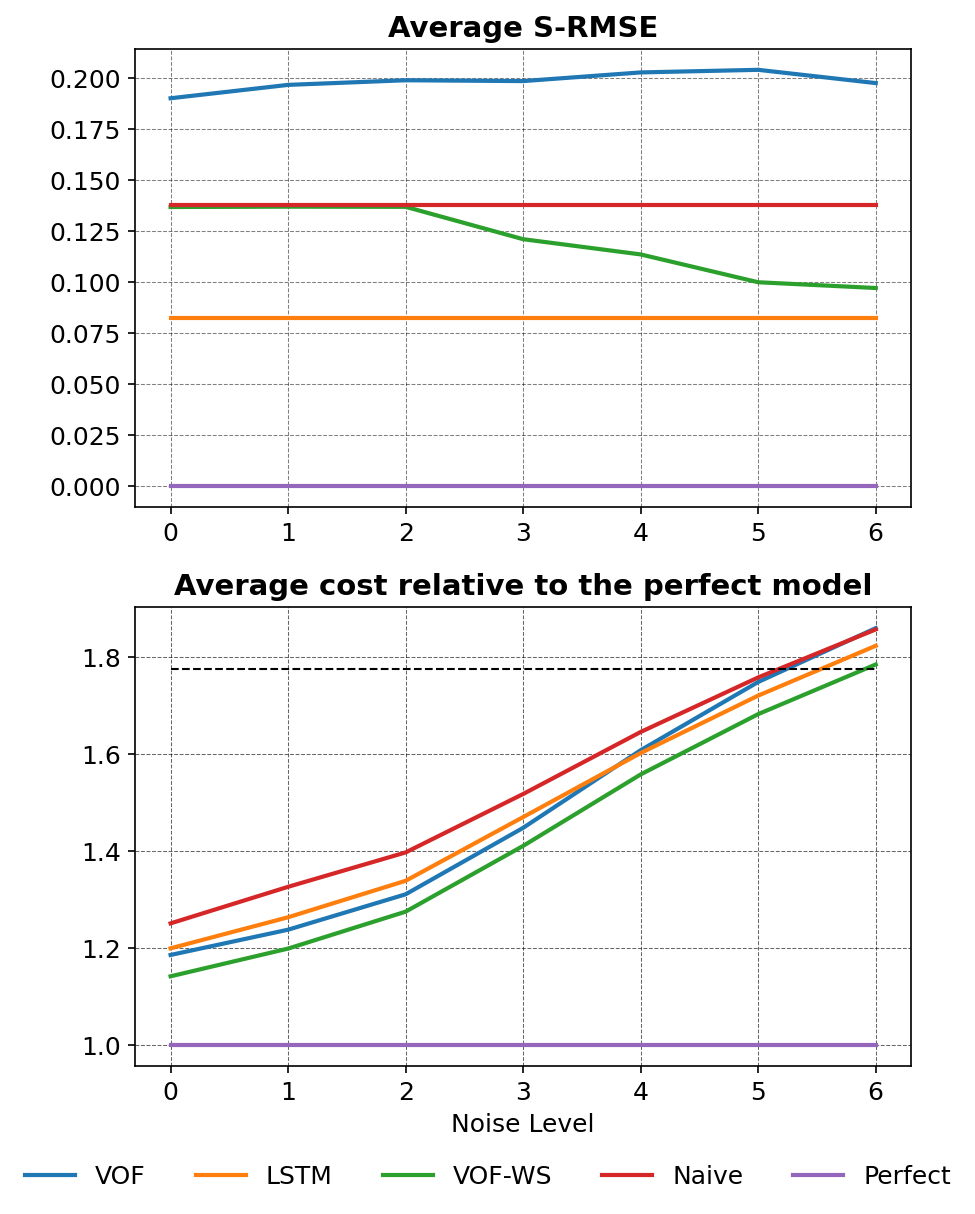

In [11]:
average_mse_df = pd.DataFrame({k: list(v.values()) for k, v in average_mse_dict.items()}, index=average_mse_dict[0].keys())
average_cost_df = pd.DataFrame({k: list(v.values()) for k, v in average_cost_dict.items()}, index=average_cost_dict[0].keys())

# Normalize cost by 'perfect' model
average_cost_df[:] = average_cost_df.values / average_cost_df.loc['perfect'].values

fig, axes = plt.subplots(2, 1, figsize=(6, 8), sharey=False)

# Plot MSE
axes[0].plot(average_mse_df.transpose().values, linewidth=2)
axes[0].set_title('Average S-RMSE', fontweight='bold', fontsize=14)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot Cost
axes[1].plot(average_cost_df.transpose().values, linewidth=2)
axes[1].plot([0, 6], [1.7765, 1.7765], linestyle='--', color='black', linewidth=1, label="No opt")
axes[1].set_title('Average cost relative to the perfect model', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Noise Level')  # Optional: adjust label if it's something else
axes[1].grid(True, linestyle='--', alpha=0.5)

# Shared legend below both plots
fig.legend(
    labels=['VOF', 'LSTM', 'VOF-WS', 'Naive', 'Perfect'],  # assumes both dfs have same index
    loc='lower center',
    ncol=len(average_mse_df.index),
    bbox_to_anchor=(0.5, -0.02),
    frameon=False
)
plt.grid(True, linestyle="--", alpha=0.6)

# Show the plot
plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.show()

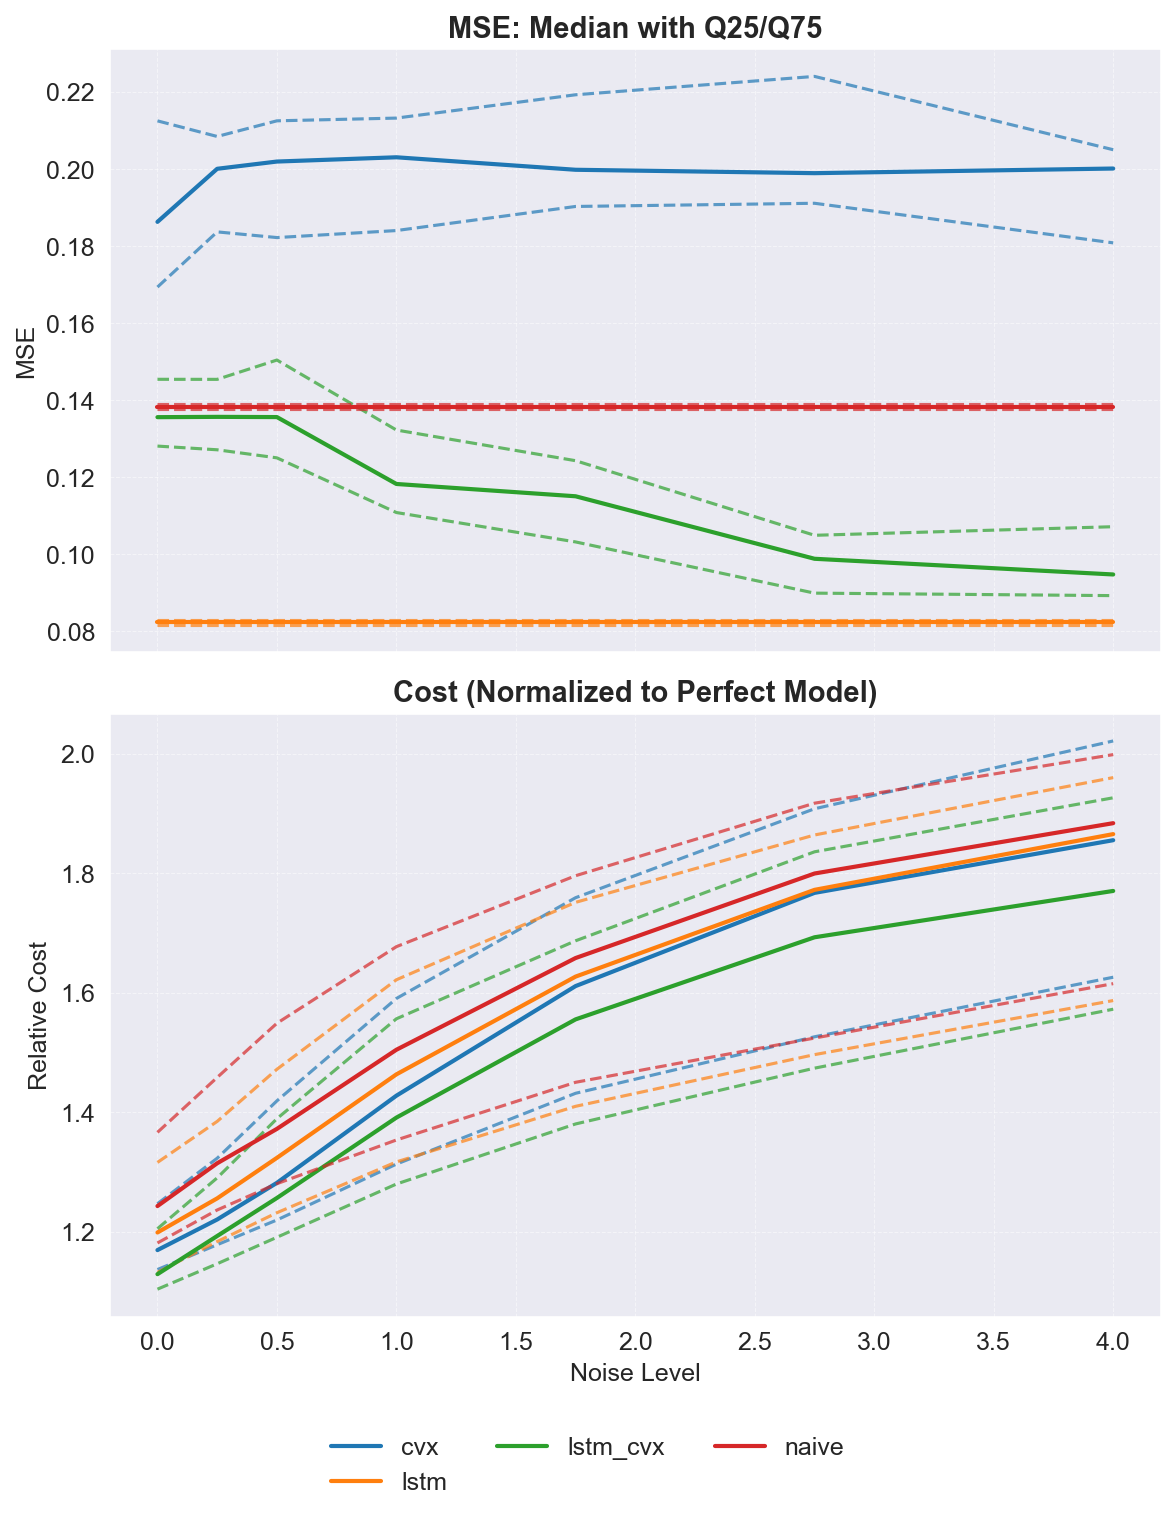

In [98]:
# Create DataFrames
median_mse_df = pd.DataFrame({k: list(v.values()) for k, v in median_mse_dict.items()}, index=median_mse_dict[0].keys())
median_cost_df = pd.DataFrame({k: list(v.values()) for k, v in median_cost_dict.items()}, index=median_cost_dict[0].keys())

q25_mse_df = pd.DataFrame({k: list(v.values()) for k, v in q25_mse_dict.items()}, index=q25_mse_dict[0].keys())
q25_cost_df = pd.DataFrame({k: list(v.values()) for k, v in q25_cost_dict.items()}, index=q25_cost_dict[0].keys())

q75_mse_df = pd.DataFrame({k: list(v.values()) for k, v in q75_mse_dict.items()}, index=q75_mse_dict[0].keys())
q75_cost_df = pd.DataFrame({k: list(v.values()) for k, v in q75_cost_dict.items()}, index=q75_mse_dict[0].keys())

# Normalize cost by 'perfect' model
perfect_model = 'perfect'
for df in [median_cost_df, q25_cost_df, q75_cost_df]:
    df[:] = df.values / df.loc[perfect_model].values

# Plotting
fig, axes = plt.subplots(2, 1, figsize=(8, 10), sharex=True)

noise_levels = list(median_mse_df.columns)
model_names = [m for m in median_mse_df.index if m != perfect_model]

# Plot MSE
for model in model_names:
    # Plot median line first and capture its color
    median_line, = axes[0].plot(noise_levels, median_mse_df.loc[model], label=f'{model}', linewidth=2)
    model_color = median_line.get_color()

    # Plot Q25 and Q75 with same color, dashed
    axes[0].plot(noise_levels, q25_mse_df.loc[model], linestyle='--', linewidth=1.5, color=model_color, alpha=0.7)
    axes[0].plot(noise_levels, q75_mse_df.loc[model], linestyle='--', linewidth=1.5, color=model_color, alpha=0.7)

axes[0].set_title('MSE: Median with Q25/Q75', fontweight='bold', fontsize=14)
axes[0].set_ylabel('MSE')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot normalized Cost
for model in model_names:
    median_line, = axes[1].plot(noise_levels, median_cost_df.loc[model], label=f'{model}', linewidth=2)
    model_color = median_line.get_color()

    axes[1].plot(noise_levels, q25_cost_df.loc[model], linestyle='--', linewidth=1.5, color=model_color, alpha=0.7)
    axes[1].plot(noise_levels, q75_cost_df.loc[model], linestyle='--', linewidth=1.5, color=model_color, alpha=0.7)

axes[1].set_title('Cost (Normalized to Perfect Model)', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Noise Level')
axes[1].set_ylabel('Relative Cost')
axes[1].grid(True, linestyle='--', alpha=0.5)

# Shared legend
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    ncol=3,
    bbox_to_anchor=(0.5, -0.02),
    frameon=False
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


In [119]:
data_folder = "../data/load_fcsts/"  # relative path

building_ids = [f"building_{i}" for i in range(27)]
to_remove = ['building_2','building_6','building_7','building_14','building_15','building_18','building_19']
for item in to_remove:
    if item in building_ids:
        building_ids.remove(item)
noise_levels = [0.25, 0.5, 1, 1.75, 2.75, 4]

dataframes = {}

for noise in noise_levels:
    df_dict = {}
    for building in building_ids:
        filename = f"{building}_{noise}_noise_forecast.npy"
        filepath = os.path.join(data_folder, filename)

        if os.path.exists(filepath):
            df_dict[building] = np.load(filepath)
        else:
            print(f"Missing file: {filename}")
            df_dict[building] = np.nan

    dataframes[noise] = pd.DataFrame(df_dict)

In [120]:
import src.data.dataprep as prep
real_dataframes = []
for building in building_ids:
    try:
        real_dataframes.append(prep.dutch_data('../data/Dutchdata_clean/' + str(building) + '.parquet', 'h', price='Realistic'))
    except:
        continue

In [137]:
noise_building_mse = []
noise_building_mape = []
noise_building_naive_mse = []
noise_building_naive_mape = []

for noise in noise_levels:
    i = 0
    noise_mse = []
    noise_mape = []
    noise_naive_mse = []
    noise_naive_mape = []
    for building in dataframes[noise].columns.values:
        noise_mse.append(mse(real_dataframes[i]['load'], dataframes[noise][building],squared=False))
        noise_mape.append(mape(real_dataframes[i]['load'], dataframes[noise][building]))
        noise_naive_mse.append(mse(real_dataframes[i]['load'][24:], real_dataframes[i]['load'][:-24],squared=False))
        noise_naive_mape.append(mape(real_dataframes[i]['load'][24:], real_dataframes[i]['load'][:-24]))
        i+=1
    noise_building_mse.append(noise_mse)
    noise_building_mape.append(noise_mape)
    noise_building_naive_mse.append(noise_naive_mse)
    noise_building_naive_mape.append(noise_naive_mape)

noise_mse_df = pd.DataFrame(noise_building_mse)
noise_mape_df = pd.DataFrame(noise_building_mape)
noise_naive_mse_df = pd.DataFrame(noise_building_naive_mse)
noise_naive_mape_df = pd.DataFrame(noise_building_naive_mape)

In [138]:
noise_mse_df.mean(axis=1)

0    0.194394
1    0.320120
2    0.469134
3    0.588083
4    0.697720
5    0.802949
dtype: float64

In [139]:
noise_mape_df.mean(axis=1)

0    0.216236
1    0.361130
2    0.581000
3    0.798123
4    1.033254
5    1.281240
dtype: float64

In [140]:
noise_naive_mse_df.mean(axis=1)

0    0.534904
1    0.534904
2    0.534904
3    0.534904
4    0.534904
5    0.534904
dtype: float64

In [141]:
noise_naive_mape_df.mean(axis=1)

0    0.749729
1    0.749729
2    0.749729
3    0.749729
4    0.749729
5    0.749729
dtype: float64

In [149]:
import glob

# Step 1: Find all matching files
files = glob.glob('../results/Epochs/' + "*_24h_*kwh_4noise.csv")

data = []

for file in files:
    # Step 2: Extract building name (e.g., 'building1')
    building_name = os.path.basename(file).split('_')[0]

    # Step 3: Read the CSV file
    df = pd.read_csv(file, index_col=0)

    # Step 4: Extract values and build a row
    row = {
        "building": building_name,
        "best epoch CVX": df.loc["CVX", "Best Epoch"],
        "best epoch LSTM-CVX": df.loc["LSTM-CVX", "Best Epoch"]
    }
    data.append(row)

# Step 5: Create final DataFrame
noise_4_df = pd.DataFrame(data).set_index("building")

In [165]:
import glob

# Step 1: Find all matching files
files = glob.glob('../results/Epochs/' + "*_24h_*kwh_0.5noise.csv")

data = []

for file in files:
    # Step 2: Extract building name (e.g., 'building1')
    building_name = os.path.basename(file).split('_')[0]

    # Step 3: Read the CSV file
    df = pd.read_csv(file, index_col=0)

    # Step 4: Extract values and build a row
    row = {
        "building": building_name,
        "time LSTM": df.loc["LSTM", "Best Epoch"],
        "time CVX": df.loc["CVX", "Best Epoch"],
        "time LSTM-CVX": df.loc["LSTM-CVX", "Best Epoch"]
    }
    data.append(row)

# Step 5: Create final DataFrame
noise_05_df = pd.DataFrame(data).set_index("building")

In [166]:
noise_4_df.mean()

best epoch CVX         104.05
best epoch LSTM-CVX     20.35
dtype: float64

In [167]:
noise_05_df.mean()

time LSTM        189.85
time CVX         128.65
time LSTM-CVX     51.70
dtype: float64

In [168]:
noise_05_df.median()

time LSTM        192.0
time CVX         142.5
time LSTM-CVX     47.0
dtype: float64

In [170]:
noise_05_df

,time LSTM,time CVX,time LSTM-CVX
building,,,
building0,192,67,80
building10,192,185,13
building11,188,185,58
building12,186,70,87
building13,192,180,21
building16,181,165,40
building17,199,123,96
building1,198,74,84
building20,198,30,17
